# Employee Productivity Lab Workbook

## 1) Imports & Settings

In [ ]:
import pandas as pd  # data loading/manipulation
import numpy as np   # numeric helpers
import matplotlib.pyplot as plt  # plotting 
from sklearn.linear_model import LinearRegression  # regression
from sklearn.metrics import r2_score  # R-squared calculation
from sklearn.preprocessing import StandardScaler  # for standardized coefficients

plt.rcParams['figure.figsize'] = (10, 6)  # larger plots
plt.rcParams['axes.grid'] = True          # light grid for readability


## 2) Load the data

In [ ]:
csv_path = 'Employee_productivity.csv'  # path to CSV file
df = pd.read_csv(csv_path)              # read CSV into DataFrame
df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


In [20]:
df.info()  # quick schema check
df.isna().sum()  # verify missing values (should be all zeros for this dataset)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   HoursWorked          300 non-null    float64
 1   FocusScore           300 non-null    float64
 2   ProductivityScore    300 non-null    float64
 3   Department           300 non-null    object 
 4   YearsAtCompany       300 non-null    int64  
 5   TeamMeetingsPerWeek  300 non-null    int64  
 6   DeskLocation         300 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 16.5+ KB


HoursWorked            0
FocusScore             0
ProductivityScore      0
Department             0
YearsAtCompany         0
TeamMeetingsPerWeek    0
DeskLocation           0
dtype: int64

## 3) Simple Linear Regressions
Compare **YearsAtCompany**, **HoursWorked**, and **FocusScore** against **ProductivityScore**.
- We'll compute R² for each and draw a scatter with a regression line.
- The highest R² is the strongest linear relationship.

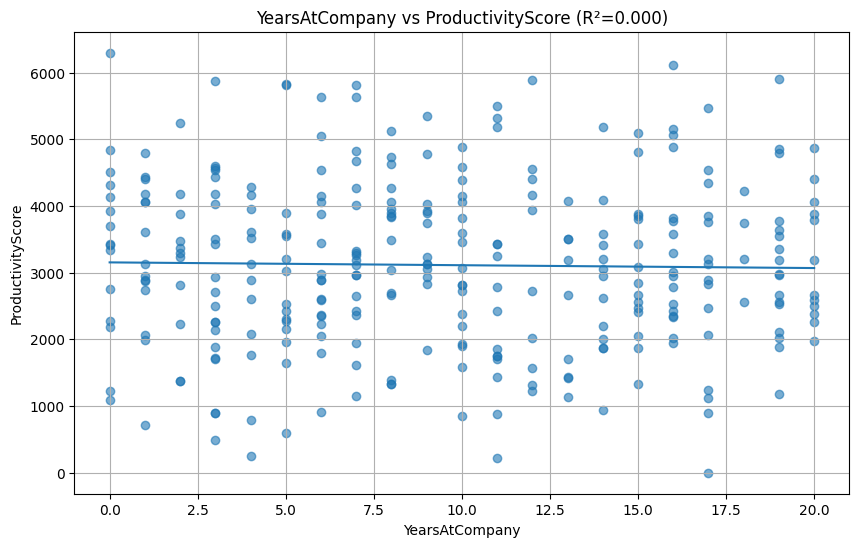

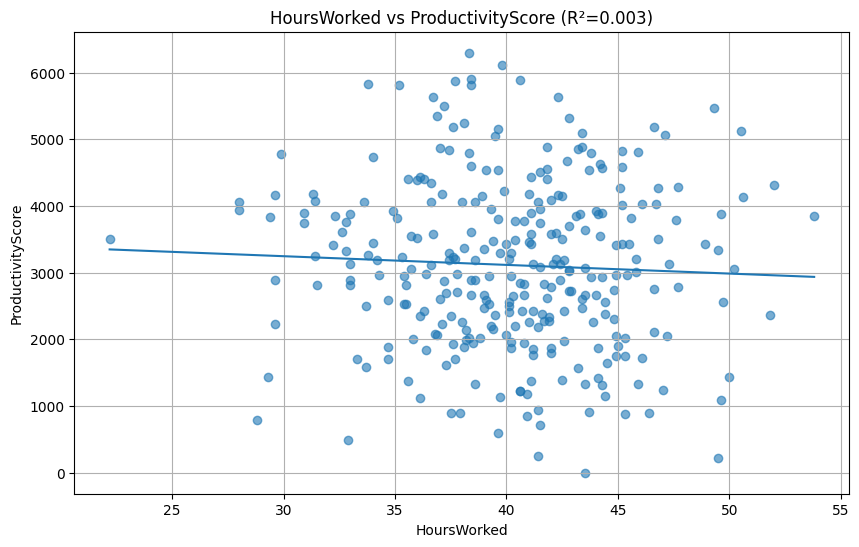

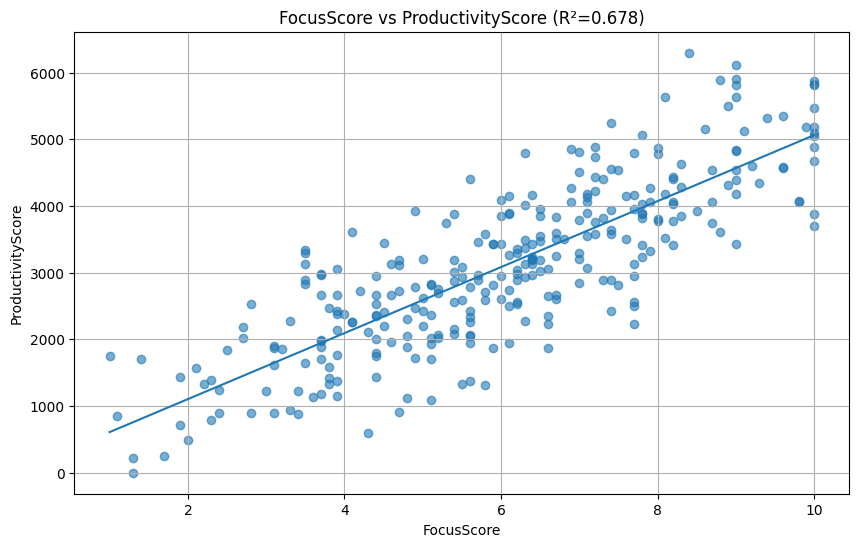

,Feature,R2
2,FocusScore,0.677696
1,HoursWorked,0.002600
0,YearsAtCompany,0.000412


In [ ]:
def simple_regression_plot(df, feature, target='ProductivityScore'):
    # Prepare X and y as 2D/1D arrays
    X = df[[feature]].values
    y = df[target].values

    # Fit linear regression
    lr = LinearRegression()
    lr.fit(X, y)
    y_pred = lr.predict(X)

    # Compute R-squared
    r2 = r2_score(y, y_pred)

    # Scatter + regression line
    plt.figure()
    plt.scatter(X, y, alpha=0.6)
    # Create a smooth line across the feature range
    x_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
    y_line = lr.predict(x_line)
    plt.plot(x_line, y_line)
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.title(f"{feature} vs {target} (R²={r2:.3f})")
    plt.show()

    return r2

# Run for the three requested features
features_to_check = ['YearsAtCompany', 'HoursWorked', 'FocusScore']
r2_results = {}
for feat in features_to_check:
    r2_results[feat] = simple_regression_plot(df, feat)

pd.DataFrame({'Feature': list(r2_results.keys()), 'R2': list(r2_results.values())}).sort_values('R2', ascending=False)

## 4) Multiple Linear Regression 
Encode categorical variables and fit a model using all predictors.

In [22]:
# One-hot encode categorical features 
df_encoded = pd.get_dummies(df, drop_first=True)

# Split features/target
X = df_encoded.drop(columns=['ProductivityScore'])
y = df_encoded['ProductivityScore']

# Fit model
lr_all = LinearRegression()
lr_all.fit(X, y)
y_pred_all = lr_all.predict(X)
overall_r2 = r2_score(y, y_pred_all)
overall_r2

0.6851104801306642

In [ ]:
# Coefficients 
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_all.coef_})\
    .sort_values(by='Coefficient', ascending=False)
coef_df

,Feature,Coefficient
1,FocusScore,512.719278
3,TeamMeetingsPerWeek,27.170621
2,YearsAtCompany,3.400789
0,HoursWorked,-4.664225
6,Department_Sales,-49.817366
4,Department_HR,-93.398401
7,DeskLocation_Private Office,-103.411959
5,Department_Marketing,-136.240520
8,DeskLocation_Remote,-229.752983


### 4a) Standardized coefficients 

In [24]:
# Standardize X for comparable coefficients
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

lr_std = LinearRegression()
lr_std.fit(X_std, y)

std_coef_df = pd.DataFrame({'Feature': X.columns, 'StdCoefficient': lr_std.coef_})\
    .sort_values(by='StdCoefficient', ascending=False)
std_coef_df

,Feature,StdCoefficient
1,FocusScore,1063.071092
3,TeamMeetingsPerWeek,47.658351
2,YearsAtCompany,20.238427
6,Department_Sales,-21.376365
0,HoursWorked,-22.747377
4,Department_HR,-41.302327
7,DeskLocation_Private Office,-49.535900
5,Department_Marketing,-58.186028
8,DeskLocation_Remote,-105.286043


## 5) Diagnostics 
- Residuals vs. Fitted to check pattern 
- Distribution of residuals 

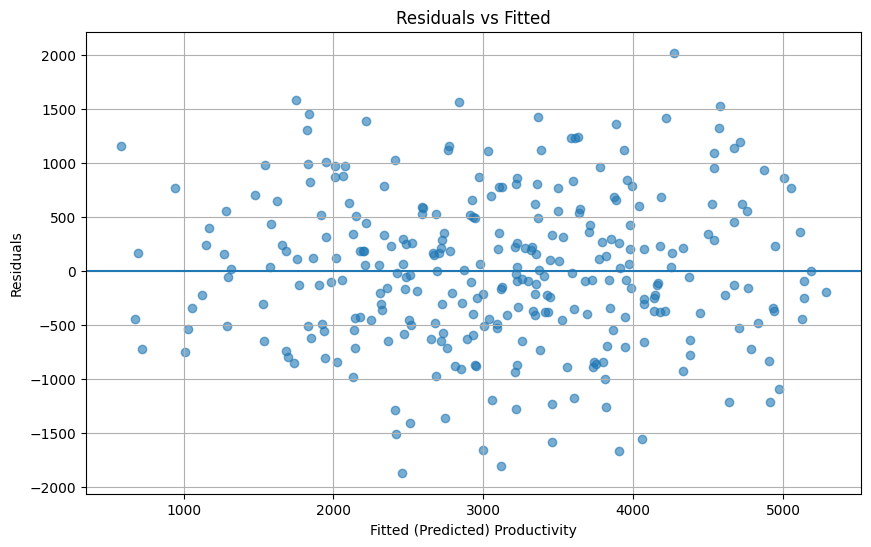

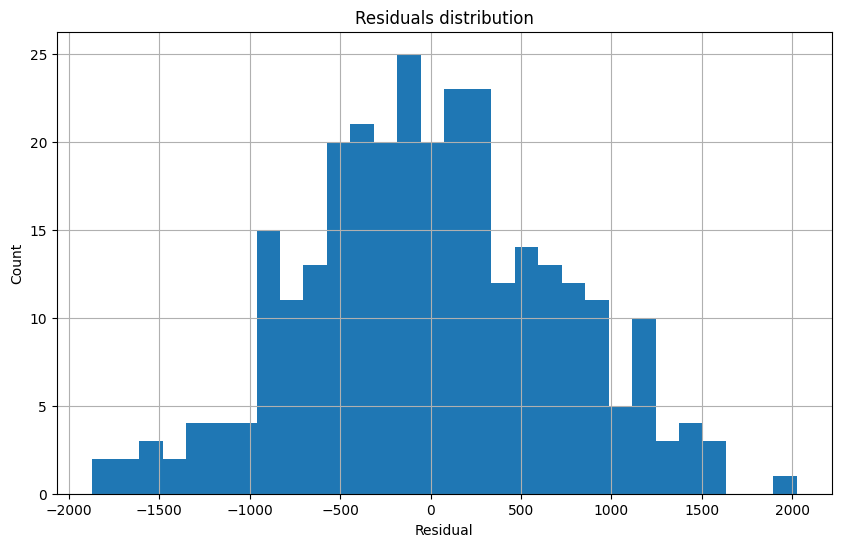

In [25]:
residuals = y - y_pred_all

# Residuals vs Fitted
plt.figure()
plt.scatter(y_pred_all, residuals, alpha=0.6)
plt.axhline(0)
plt.xlabel('Fitted (Predicted) Productivity')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

# Histogram of residuals
plt.figure()
plt.hist(residuals, bins=30)
plt.title('Residuals distribution')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.show()

**Summary:**  
Focus is the strongest driver of productivity, while years at the company and hours worked show almost no relationship. The full model suggests that too many hours can slightly reduce productivity, and remote or private office setups, along with HR and Marketing roles, are linked to lower scores compared to Engineering and open-plan desks.  

**Recommendations:**  
Employees will be most productive if the company prioritizes improving focus, reduces unnecessary overtime, streamlines administrative tasks, keeps meetings purposeful, and ensures remote and private office staff have the resources they need to succeed.
